In [80]:
import stim
import random

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
code = "20_2_6"
max_col_ops = 100

random.seed("102")

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X", top_n=50, num_circuits=1
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

Loading QECC: 20_2_6
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100, num_circuits=1)...


Finding unique matrix configuration: 100%|██████████| 1/1 [00:01<00:00,  1.41s/it]

Cost of final M: 16
Chosen CNOT gates: [(8, 7), (8, 0), (4, 0), (3, 5), (3, 2), (8, 3), (9, 11), (15, 10), (0, 11), (9, 5), (15, 6), (0, 6), (7, 9), (0, 7), (2, 15), (0, 2), (0, 12), (5, 0)]
Computing initial single faults...

Running verification stabilizers search for t=3 layers (top_n=50, first_layer=X)...

--- X Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 40.260000000000005
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 48.3
  [Layer 3] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 48.3
  [Chosen Stabilizers] (Violations: 4)
    -> Layer 1: ['00011000000011001001', '00100010010010000011', '01000100001000110001']
    -> Layer 2: ['00001001000001001110', '00100010000000110000', '00111010101000000000', '01001000001001000000', '01001001010010000001']
    -> Layer 3: ['10000100000010000001']
  - Layer 1, Qubit 2, Stab 1, Amount: 1
  - Layer 1, Qubit 14,

Finding unique matrix configuration: 100%|██████████| 1/1 [00:48<00:00, 48.08s/it]


--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 39
Num CX: 150
Total instructions: 182
Depth: 52


Total Qubits: 39
Num CX: 150
Total instructions: 182
Depth: 52


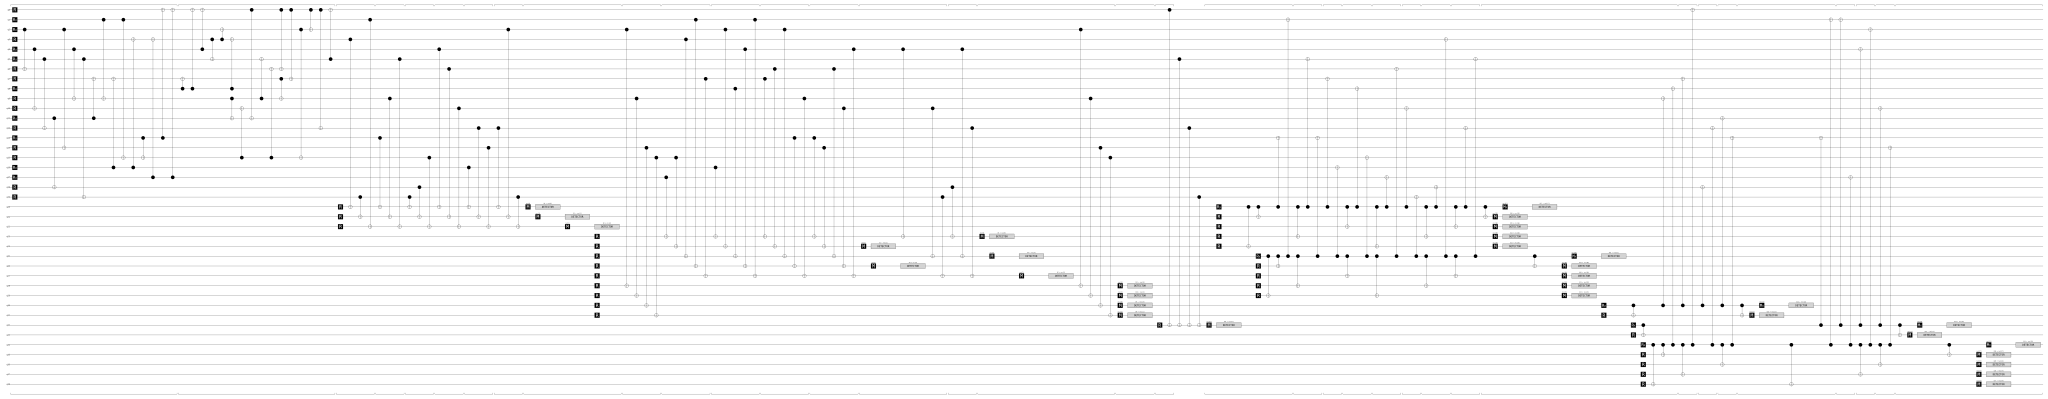

In [82]:
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

final_circ.diagram('timeline-svg')

In [83]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]]


In [108]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=6, t=3)...
    [FAIL] Catastrophic cascade found!
    W(E_init)=3 faults bypassed flags to require only W(E_data)=2 to fail.
    Extracting unified failure circuit (Prep Faults + Data Faults)...
Verification Result: False


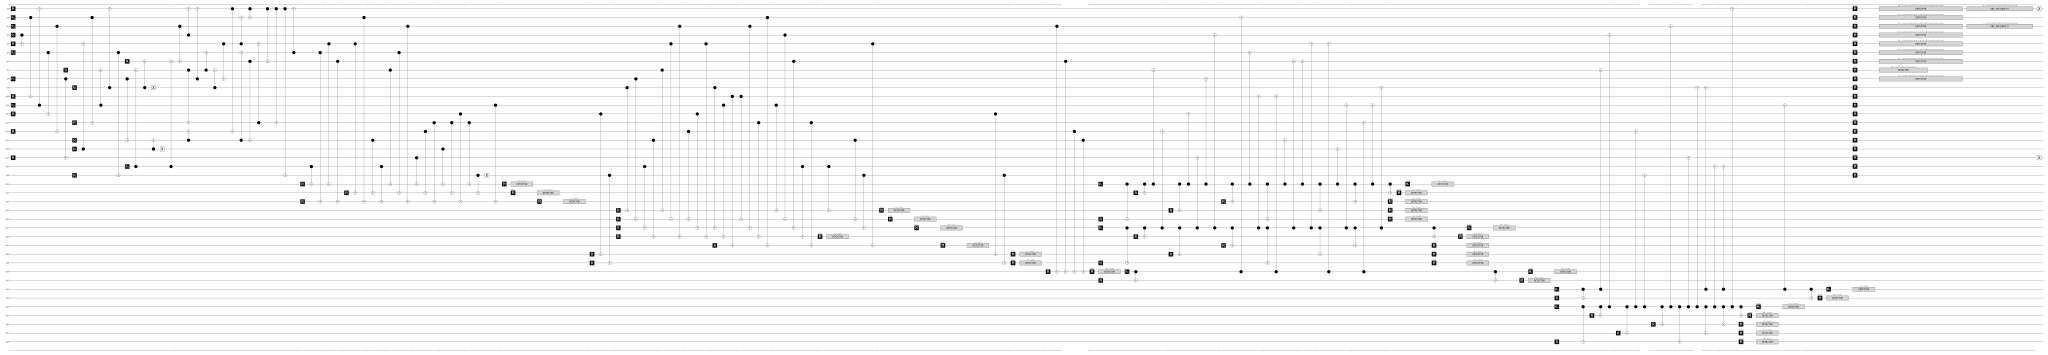

In [102]:
res_exhaustive.diagram("timeline-svg")

In [86]:
if False:
    file = get_project_root().joinpath("good_circuits", f"{code}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

Num CX: 30
Total instructions: 33
Depth: 18


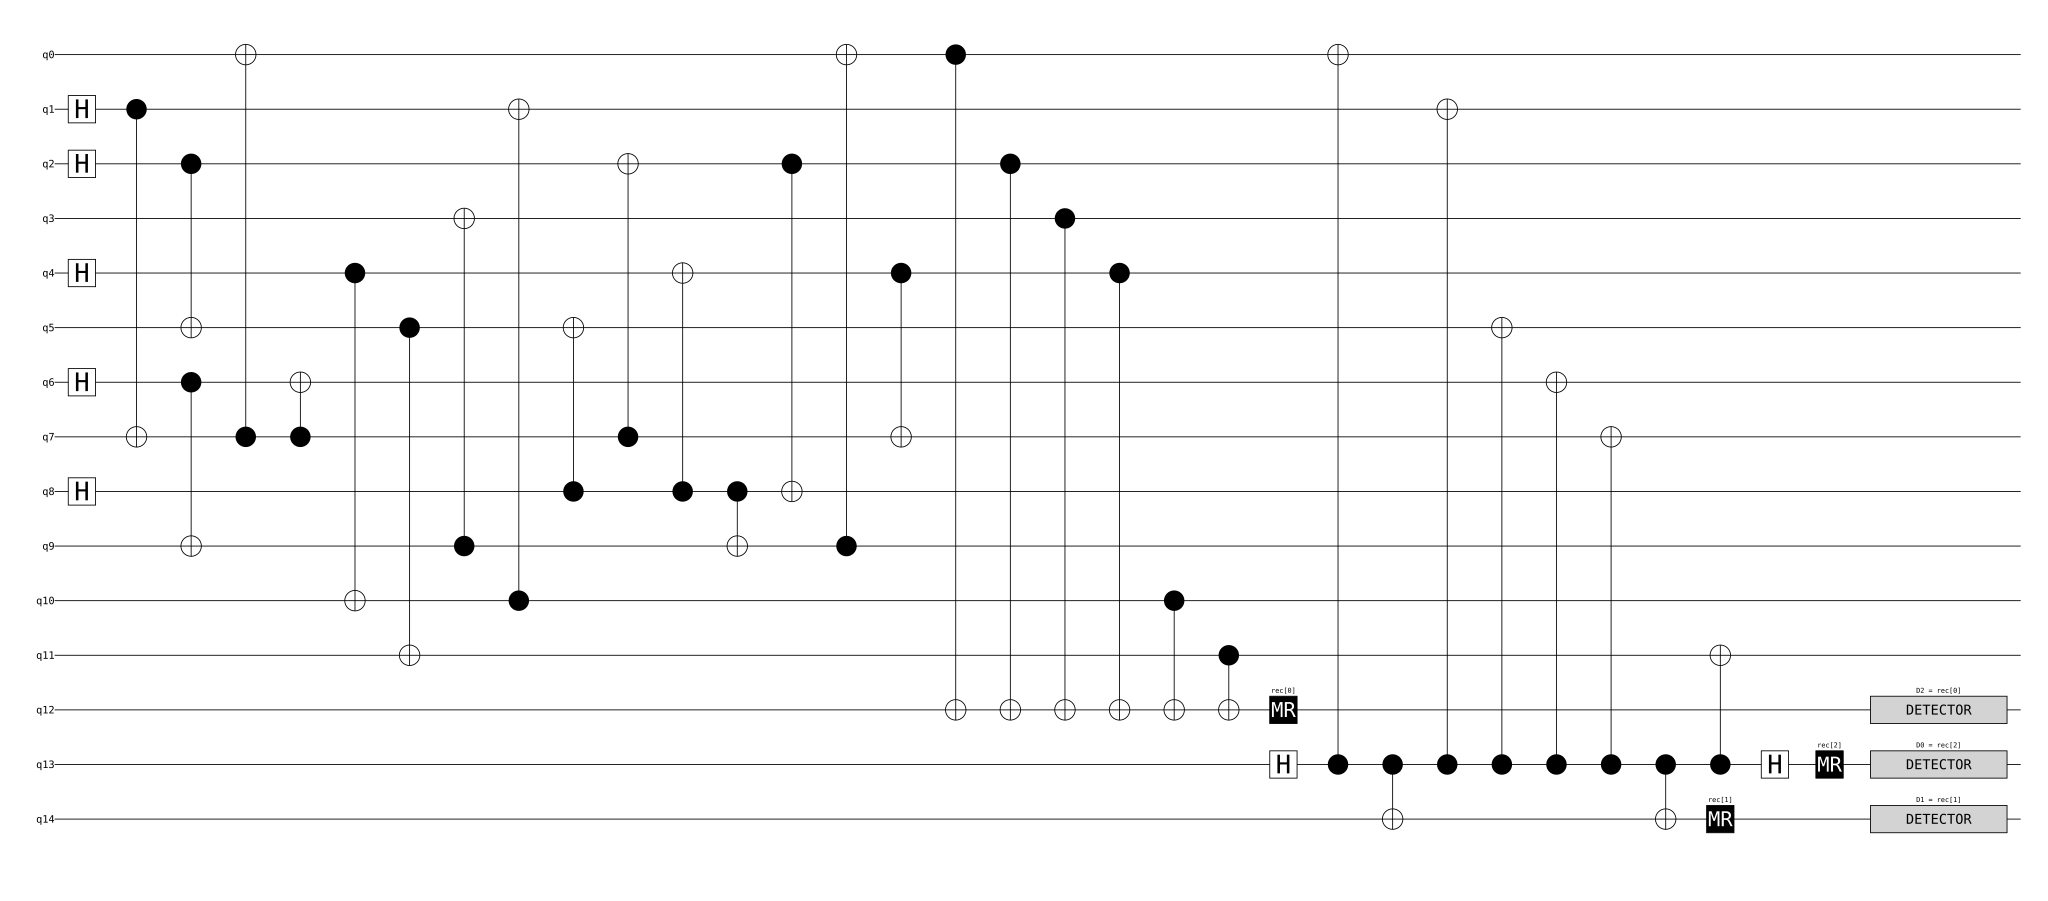

In [87]:
bens_circ = qasm_to_stim("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[69];
creg c[38];
h q[68];
h q[66];
h q[67];
h q[60];
h q[61];
h q[62];
h q[63];
h q[64];
h q[65];
h q[52];
h q[53];
h q[54];
h q[51];
h q[46];
h q[47];
h q[48];
h q[49];
h q[50];
h q[39];
h q[40];
h q[37];
h q[38];
h q[31];
h q[32];
h q[33];
h q[0];
h q[1];
h q[2];
h q[4];
h q[5];
h q[6];
h q[8];
h q[10];
h q[12];
h q[14];
h q[16];
h q[18];
h q[20];
h q[21];
h q[22];
cx q[67], q[59];
cx q[48], q[41];
cx q[49], q[43];
cx q[50], q[45];
cx q[39], q[42];
cx q[37], q[36];
cx q[38], q[35];
cx q[2], q[9];
cx q[4], q[15];
cx q[0], q[23];
cx q[18], q[26];
cx q[20], q[28];
cx q[14], q[25];
cx q[5], q[7];
cx q[21], q[29];
cx q[22], q[30];
cx q[39], q[37];
cx q[21], q[36];
cx q[9], q[3];
cx q[4], q[24];
cx q[2], q[11];
cx q[23], q[17];
cx q[0], q[27];
cx q[6], q[14];
cx q[16], q[26];
cx q[22], q[29];
cx q[18], q[19];
cx q[30], q[28];
cx q[52], q[37];
cx q[24], q[41];
cx q[40], q[21];
cx q[18], q[35];
cx q[32], q[28];
cx q[8], q[9];
cx q[10], q[11];
cx q[3], q[25];
cx q[20], q[23];
cx q[2], q[26];
cx q[16], q[17];
cx q[14], q[15];
cx q[0], q[22];
cx q[52], q[10];
cx q[24], q[13];
cx q[40], q[42];
cx q[39], q[18];
cx q[15], q[35];
cx q[28], q[36];
cx q[31], q[17];
cx q[33], q[9];
cx q[1], q[3];
cx q[12], q[25];
cx q[29], q[23];
cx q[4], q[16];
cx q[31], q[55];
cx q[18], q[56];
cx q[15], q[59];
cx q[24], q[7];
cx q[13], q[27];
cx q[40], q[28];
cx q[11], q[36];
cx q[33], q[17];
cx q[32], q[29];
cx q[5], q[25];
cx q[23], q[30];
cx q[1], q[0];
cx q[61], q[59];
cx q[18], q[43];
cx q[31], q[14];
cx q[52], q[11];
cx q[24], q[34];
cx q[12], q[13];
cx q[27], q[19];
cx q[9], q[36];
cx q[17], q[35];
cx q[32], q[16];
cx q[8], q[0];
cx q[14], q[59];
cx q[18], q[44];
cx q[31], q[7];
cx q[8], q[57];
cx q[40], q[11];
cx q[4], q[34];
cx q[26], q[27];
cx q[25], q[24];
cx q[39], q[9];
cx q[3], q[36];
cx q[5], q[35];
cx q[33], q[16];
cx q[32], q[30];
cx q[10], q[0];
h q[52];
measure q[52] -> c[0];
cx q[62], q[57];
cx q[8], q[58];
cx q[53], q[18];
cx q[46], q[44];
cx q[31], q[41];
cx q[40], q[17];
cx q[6], q[4];
measure q[34] -> c[1];
cx q[3], q[45];
cx q[39], q[7];
cx q[12], q[35];
cx q[23], q[36];
cx q[33], q[1];
cx q[63], q[58];
cx q[31], q[55];
cx q[54], q[18];
cx q[11], q[44];
cx q[24], q[41];
cx q[17], q[43];
cx q[39], q[5];
cx q[40], q[23];
cx q[27], q[35];
cx q[33], q[6];
cx q[31], q[13];
cx q[18], q[56];
cx q[11], q[57];
cx q[51], q[44];
cx q[53], q[17];
cx q[16], q[43];
cx q[39], q[1];
cx q[40], q[27];
cx q[6], q[35];
measure q[55] -> c[2];
cx q[18], q[58];
cx q[31], q[19];
cx q[9], q[44];
cx q[38], q[35];
cx q[66], q[58];
cx q[18], q[59];
cx q[31], q[4];
cx q[32], q[19];
cx q[9], q[57];
cx q[47], q[44];
h q[38];
measure q[38] -> c[3];
cx q[11], q[58];
cx q[64], q[59];
cx q[19], q[42];
cx q[33], q[4];
cx q[31], q[26];
cx q[16], q[44];
cx q[60], q[58];
cx q[17], q[59];
cx q[39], q[19];
cx q[31], q[25];
cx q[32], q[26];
cx q[53], q[16];
cx q[46], q[44];
cx q[68], q[58];
cx q[24], q[58];
cx q[61], q[59];
cx q[54], q[26];
cx q[25], q[41];
cx q[40], q[19];
cx q[39], q[33];
cx q[32], q[0];
h q[31];
measure q[31] -> c[4];
cx q[1], q[44];
h q[46];
measure q[46] -> c[5];
cx q[63], q[58];
cx q[48], q[41];
cx q[25], q[35];
cx q[19], q[42];
cx q[33], q[10];
cx q[0], q[2];
h q[32];
measure q[32] -> c[6];
h q[39];
measure q[39] -> c[7];
cx q[51], q[44];
cx q[1], q[45];
h q[61];
measure q[61] -> c[8];
cx q[65], q[58];
h q[63];
measure q[63] -> c[9];
measure q[41] -> c[10];
cx q[19], q[43];
measure q[35] -> c[11];
cx q[40], q[10];
cx q[33], q[2];
measure q[42] -> c[12];
h q[48];
measure q[48] -> c[13];
cx q[27], q[44];
cx q[0], q[45];
h q[51];
measure q[51] -> c[14];
cx q[25], q[58];
cx q[10], q[57];
cx q[53], q[19];
cx q[49], q[43];
h q[33];
measure q[33] -> c[15];
h q[40];
measure q[40] -> c[16];
cx q[0], q[59];
cx q[47], q[44];
cx q[60], q[58];
cx q[62], q[57];
cx q[53], q[56];
cx q[54], q[19];
measure q[43] -> c[17];
h q[49];
measure q[49] -> c[18];
cx q[2], q[44];
h q[47];
measure q[47] -> c[19];
cx q[1], q[58];
h q[60];
measure q[60] -> c[20];
measure q[57] -> c[21];
h q[53];
measure q[53] -> c[22];
cx q[54], q[56];
cx q[2], q[36];
measure q[44] -> c[23];
h q[62];
measure q[62] -> c[24];
cx q[19], q[58];
cx q[54], q[27];
cx q[37], q[36];
measure q[56] -> c[25];
cx q[65], q[58];
cx q[27], q[59];
h q[54];
measure q[54] -> c[26];
measure q[36] -> c[27];
h q[37];
measure q[37] -> c[28];
cx q[66], q[58];
h q[65];
measure q[65] -> c[29];
cx q[64], q[59];
cx q[2], q[58];
h q[64];
measure q[64] -> c[30];
h q[66];
measure q[66] -> c[31];
cx q[68], q[58];
cx q[2], q[45];
measure q[58] -> c[32];
cx q[2], q[59];
cx q[50], q[45];
cx q[67], q[59];
measure q[45] -> c[33];
h q[50];
measure q[50] -> c[34];
measure q[59] -> c[35];
h q[67];
measure q[67] -> c[36];
h q[68];
measure q[68] -> c[37];
""")
bens_circ = stim.Circuit("""H 1 2 4 6 8
CX 1 7 6 9 2 5 7 0 7 6 4 10 5 11 9 3 10 1 8 5 7 2 8 4 8 9 2 8 9 0 4 7 0 12 2 12 3 12 4 12 10 12 11 12
MR 12
H 13
CX 13 0 13 14 13 1 13 5 13 6 13 7 13 14
MR 14
CX 13 11
H 13
MR 13
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

In [88]:
circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
flags = samples[:, :-H_z.shape[1]]
meas_samples = samples[:, -H_z.shape[1]:]
print(flags.astype(int))
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]
[[0 0 1 0 1 1 0 0 1]
 [1 1 0 0 0 0 1 1 0]
 [0 0 1 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 1 0 0 1]
 [0 1 0 0 1 1 0 0 1]
 [1 0 1 0 1 1 1 1 0]
 [1 1 0 1 0 0 0 0 1]
 [1 0 0 1 1 1 0 0 0]
 [1 1 0 1 0 0 0 0 1]]
[[1 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]]


In [105]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
    prep_circ=bens_circ,
    H_primary=H_z, L_primary=np.atleast_2d(L_z),
    H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
    d=d, t=d // 2,
    primary_basis="Z", conjugate_basis="X",
    verbose=True
)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=6, t=3)...


ValueError: The circuit contains non-deterministic observables.
The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D3', 'D4', 'D5', 'D9', 'D10', 'D11', 'L0', 'L1', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords D3:D4:D5:D9:D10:D11:L0:L1 > output_image.svg

This was discovered while analyzing qubit initialization into |0> at the start of the circuit on:
    qubit 1

The collapse anti-commuted with these detectors/observables:
    D3
    D4
    D5
    D9
    D10
    D11
    L0
    L1

The backward-propagating error sensitivity for D3 was:
    Z0
    X1
    X2
    Z5
    Z7
    Z11
    Z15
    Z16
    Z17

The backward-propagating error sensitivity for D4 was:
    X1
    X4
    X6
    X8
    Z9
    Z10
    X13
    Z16
    Z17
    Z18
    Z1

In [110]:
final_circ = stim.Circuit("""
R 0
RX 1 2 3
R 4
RX 5
R 6 7
RX 8 9
R 10
RX 11
R 12 13 14 15
RX 16
R 17
RX 18
R 19
CX 3 4 1 10 11 0 5 12 2 14 8 17 16 4 1 13 11 7 9 0 5 19 8 15 18 7 9 6 16 15 18 6
TICK
CX 2 6 3 0 8 0 7 13 7 5 9 7 15 14 4 8 0 14 15 5 4 1 0 1 6 15 0 6 13 4 0 13 0 19 5 0
TICK
R 20 21 22
CX 18 20 5 22
TICK
CX 4 20 6 22
TICK
CX 4 21 1 22
TICK
CX 15 21 18 22
TICK
CX 7 20 5 21 2 22
TICK
CX 17 20 14 21 13 22
R 28 29
TICK
CX 12 28 19 29
TICK
CX 16 20 13 21 12 22
TICK
CX 13 20 19 21 11 22
TICK
M 20
DETECTOR rec[-1]
M 21
DETECTOR rec[-1]
M 22
DETECTOR rec[-1]
R 23 24 25 26 27
TICK
CX 9 23 8 24 18 25 15 26
TICK
CX 7 23 4 24 2 26
TICK
CX 14 24 12 25 4 26
TICK
CX 9 25 11 26 10 27
TICK
CX 10 24 2 25 13 26 1 27
TICK
CX 11 23 3 24 6 25 18 26 13 27
TICK
M 26
DETECTOR rec[-1]
CX 18 23 15 24 19 25 4 27
TICK
M 23
DETECTOR rec[-1]
M 24
DETECTOR rec[-1]
M 25
DETECTOR rec[-1]
M 27
DETECTOR rec[-1]
CX 12 28 19 29
TICK
M 28 29
DETECTOR rec[-1]
DETECTOR rec[-2]
TICK
R 30
CX 2 30
TICK
CX 6 30
TICK
CX 14 30
TICK
CX 15 30
TICK
M 30
DETECTOR rec[-1]
R 21 22 23 24
RX 20
CX 20 24 20 21
R 26 27 28 29
RX 25
CX 25 29 25 26
R 31
RX 30
CX 30 31 20 7 25 14
TICK
CX 20 23 25 28 20 12 25 17
TICK
CX 20 8 25 3
TICK
CX 20 22 25 27 20 5 25 10 30 1
TICK
CX 20 24 25 29 20 15 25 6 30 10
TICK
CX 20 6 25 4
TICK
CX 20 23 25 28 20 16 25 11 30 4
TICK
CX 20 22 25 27 20 11 25 9 30 13
TICK
CX 20 21
M 21 22 23 24
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
MX 20
DETECTOR rec[-1]
CX 25 26
M 26 27 28 29
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
MX 25
DETECTOR rec[-1]
CX 30 31
M 31
DETECTOR rec[-1]
MX 30
DETECTOR rec[-1]
R 33
RX 32
CX 32 33
R 35 36 37 38
RX 34
CX 34 38 34 35 32 7 34 3
TICK
CX 34 37 34 14
TICK
CX 34 19
TICK
CX 34 36 34 2
TICK
CX 34 38 34 17
TICK
CX 34 9
TICK
CX 34 37 32 9 34 18
TICK
CX 34 36 32 18 34 0
TICK
CX 34 35
M 35 36 37 38
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
MX 34
DETECTOR rec[-1]
CX 32 11
TICK
CX 32 33
M 33
DETECTOR rec[-1]
MX 32
DETECTOR rec[-1]
""")

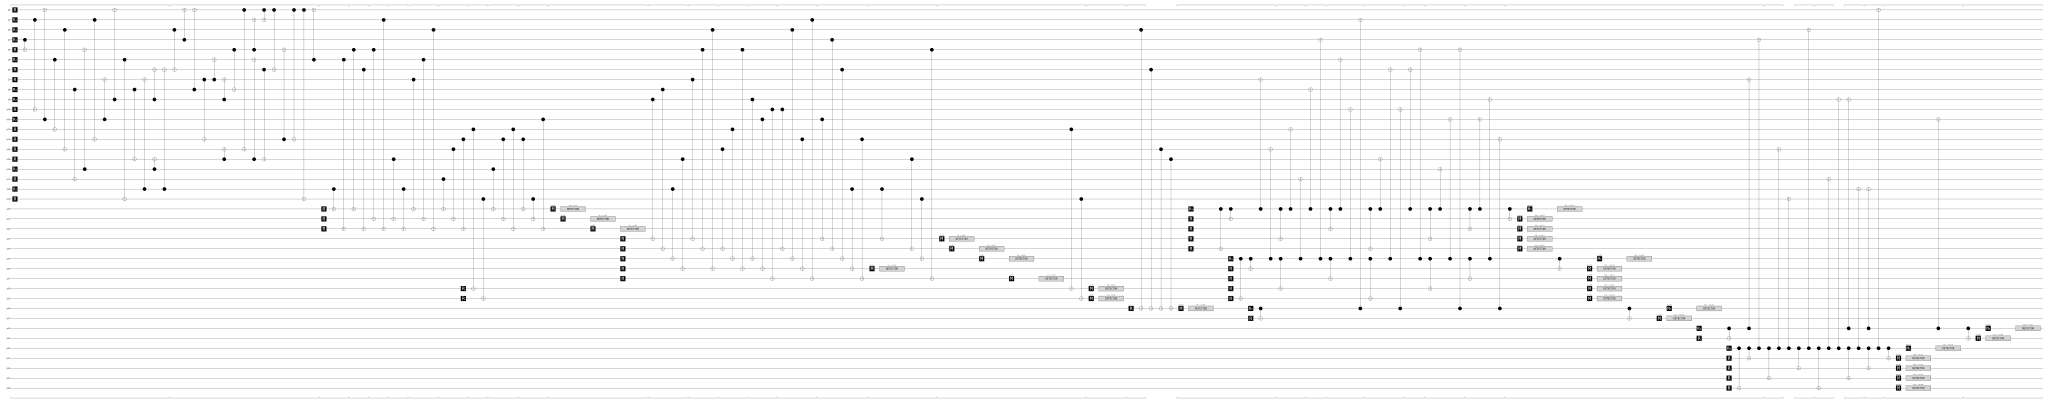

In [111]:
final_circ.diagram('timeline-svg')

In [112]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=6, t=3)...
    [FAIL] Catastrophic cascade found!
    W(E_init)=3 faults bypassed flags to require only W(E_data)=2 to fail.
    Extracting unified failure circuit (Prep Faults + Data Faults)...
Verification Result: False


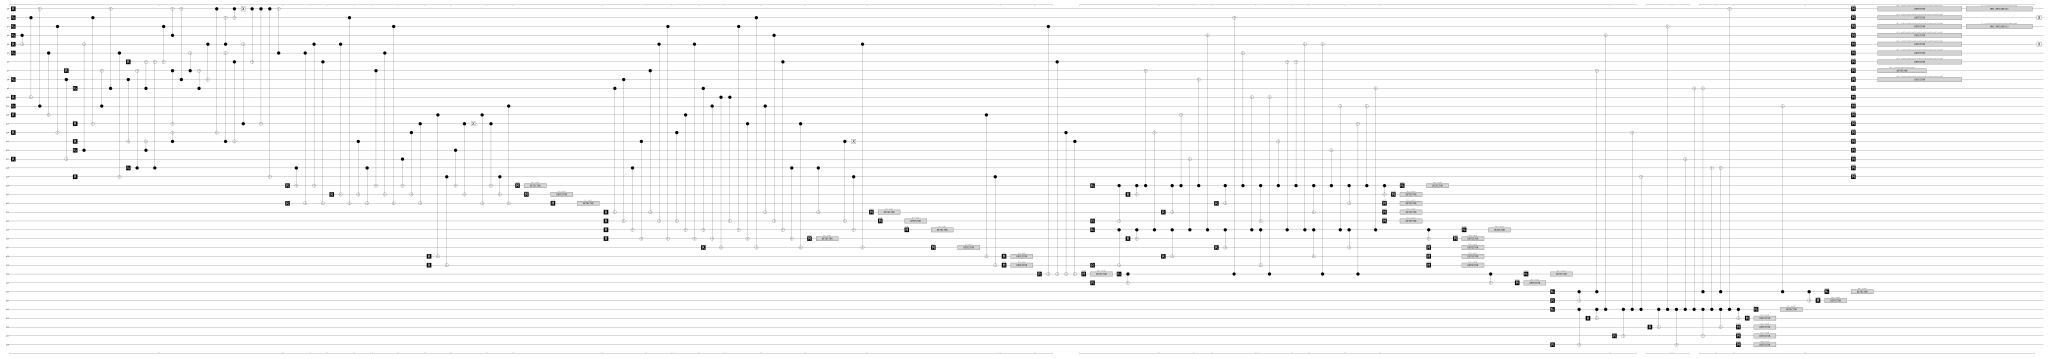

In [113]:
res_exhaustive.diagram("timeline-svg")